Gradient Descent


Gradient Descent is an algorithm that finds the local extrema of a function. This is applicable to machine learning, because we want to find the optimal parameters that minimize our loss function. In machine learning, loss functions quantify the amount of error between the predicted values from a machine learning model and the actual expected values. In this notebook, we will perform linear regression by using gradient descent to find the optimal slope and y-intercept.

Importing the libraries

In [1]:
pip install scienceplots

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install Ipython

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install celluloid

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from IPython.display import display, Latex, Image
from celluloid import Camera

np.random.seed(0)
plt.style.use(["science" , "no-latex"])

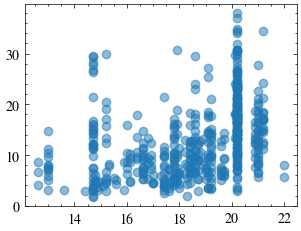

In [5]:
fname = "REGRESSION-gradidentDescent-data.txt"
x , y = np.loadtxt(fname , delimiter = ",", unpack =True , skiprows = 1 , usecols = (10,12))
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(x,y , color = "#1f77b4" , marker = "o" , alpha = 0.5 , label = "data")

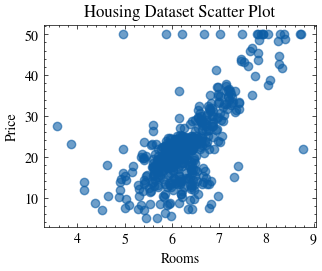

In [6]:
import numpy as np
import matplotlib.pyplot as plt

fname = "REGRESSION-gradidentDescent-data.txt"

# load data
data = np.loadtxt(fname, delimiter=",")

# Example: RM (rooms) vs MEDV (price)
x = data[:, 5]   # average number of rooms
y = data[:, -1]  # house price

plt.scatter(x, y, alpha=0.6)
plt.xlabel("Rooms")
plt.ylabel("Price")
plt.title("Housing Dataset Scatter Plot")
plt.show()

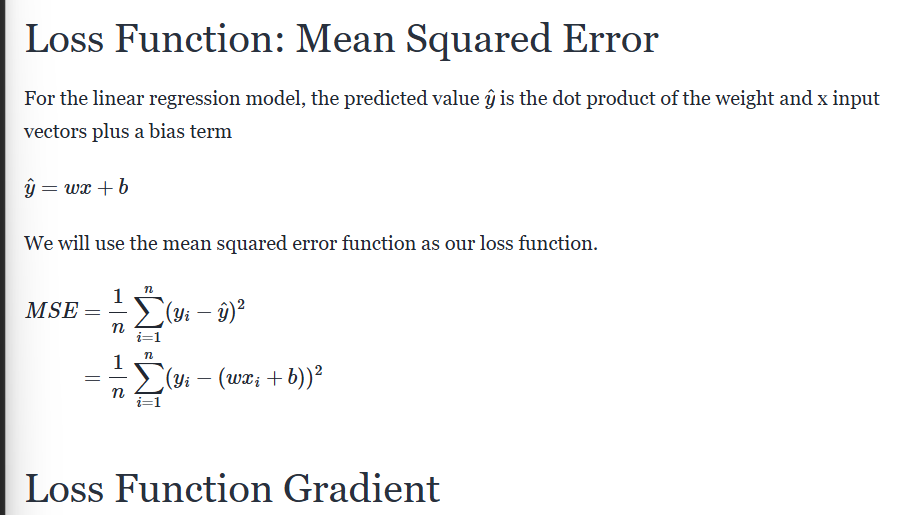

Loss Function Gradient

In [7]:
def mse_loss(x , y, w , b):
    return np.mean(np.square(y - (w * x + b)))

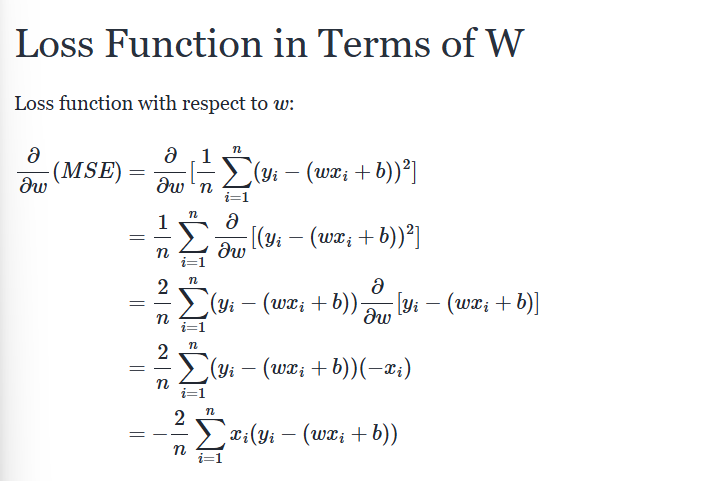

In [8]:
def mse_loss_dw(x,y,w,b):
    return -2 * np.mean(x * (y - (w * x + b)))


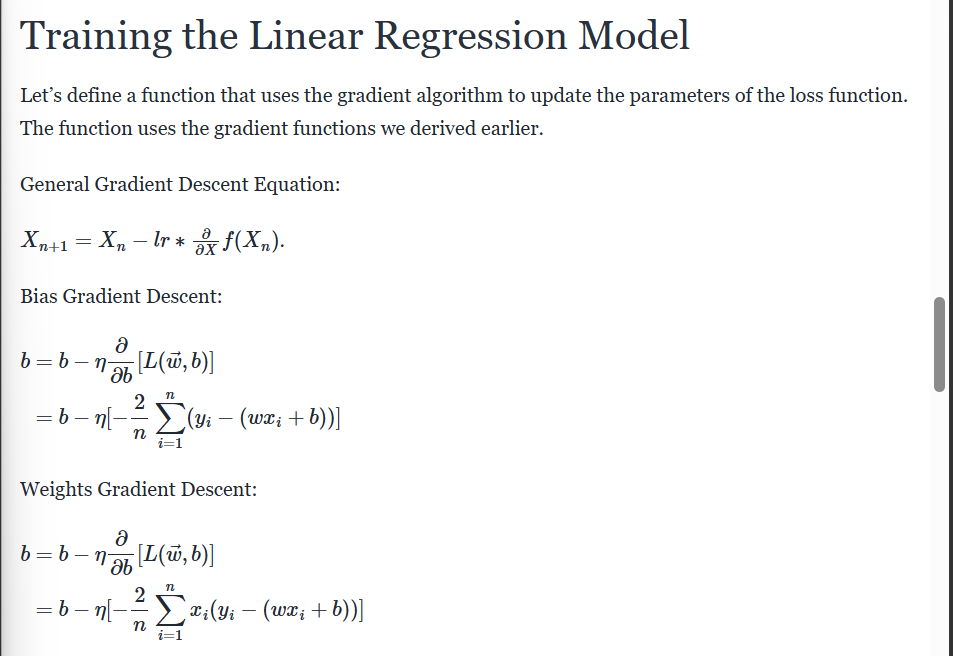

In [9]:
def update_weights(x,y,w,b , learning_rate):
    #update w and b 
    w  = w - mse_loss_dw(x,y,w,b) * learning_rate
    b  = b - mse_loss_db(x,y,w,b) * learning_rate
    return w, b

Graphing function

Let's define helper functions to plot the graphs.

In [10]:
def create_plots():
    plt.ioff()
    fig = plt.figure(figsize=(16 / 9.0 * 4, 4 * 1), layout="constrained")
    fig.suptitle("Gradient Descent")
    ax0 = fig.add_subplot(1, 2, 1)
    ax0.set_xlabel("Spending", fontweight="normal")
    ax0.set_ylabel("Sales", fontweight="normal")
    ax0.set_title("Linear Regression")

    ax1 = fig.add_subplot(1, 2, 2, projection="3d")
    ax1.set_xlabel("Slope, w")
    ax1.set_ylabel("Intercept, b")
    ax1.set_zlabel("Error")
    ax1.set_title("Error")
    ax1.view_init(15, -35)

    camera = Camera(fig)
    return ax0, ax1, camera


def generate_error_range(x, y, N, w_max, b_max):
    w_range = np.arange(0, w_max, w_max / N)
    b_range = np.arange(0, b_max, b_max / N)
    w_range, b_range = np.meshgrid(w_range, b_range)
    w_range = w_range.flatten()
    b_range = b_range.flatten()

    error_range = np.array([])
    for i in range(min(w_range.shape[0], b_range.shape[0])):
        error_range = np.append(error_range, mse_loss(x, y, w_range[i], b_range[i]))

    return w_range, b_range, error_range

Tranning the data

In [21]:
def update_w_and_b(x, y, w, b, learning_rate):
    m = len(x)
    dw = (1/m) * np.sum((w * x + b - y) * x)
    db = (1/m) * np.sum(w * x + b - y)
    w -= learning_rate * dw
    b -= learning_rate * db
    return w, b

In [22]:
def train(x, y, w0, b0, learning_rate, epochs, output_filename):
    w = w0
    b = b0

    ax0, ax1, camera = create_plots()
    loss_dims = 20
    w_max = 0.5
    b_max = 15
    w_range, b_range, error_range = generate_error_range(x, y, loss_dims, w_max, b_max)

    for e in range(epochs):
        w, b = update_w_and_b(x, y, w, b, learning_rate) # type: ignore
        if (
            (e == 0)
            or (e < 60 and e % 5 == 0)
            or (e < 3000 and e % 1000 == 0)
            or (e % 3000 == 0)
        ):
            # Plot the error given the current slope and y-intercept
            ax1.scatter(w_range, b_range, error_range, color="blue", alpha=0.05) # type: ignore
            ax1.scatter([w], [b], [mse_loss(x, y, w, b)], color="red", s=100) # type: ignore

            # Plot the linear regression lines
            ax0.scatter(x, y, color="#1f77b4", marker="o", alpha=0.25)
            X_plot = np.linspace(0, 50, 50)
            ax0.plot(X_plot, X_plot * w + b, color="black")

            # print the loss
            print("epoch: ", str(e), "loss: " + str(mse_loss(x, y, w, b)))
            camera.snap()

    animation = camera.animate()
    animation.save(output_filename, writer="pillow")
    plt.show()

    return w, b


Let's train the linear regerssion model on a sample dataset

epoch:  0 loss: 205.65506029547328
epoch:  5 loss: 179.92642340650585
epoch:  10 loss: 158.32323595125487
epoch:  15 loss: 140.18400392266653
epoch:  20 loss: 124.95330038065909
epoch:  25 loss: 112.16475815866835
epoch:  30 loss: 101.42678959978852
epoch:  35 loss: 92.41059605772824
epoch:  40 loss: 84.84010001089956
epoch:  45 loss: 78.4834915087876
epoch:  50 loss: 73.14613010095418
epoch:  55 loss: 68.66458490420135
epoch:  1000 loss: 45.19500016100158
epoch:  2000 loss: 45.19316497727824
epoch:  3000 loss: 45.19133226388232


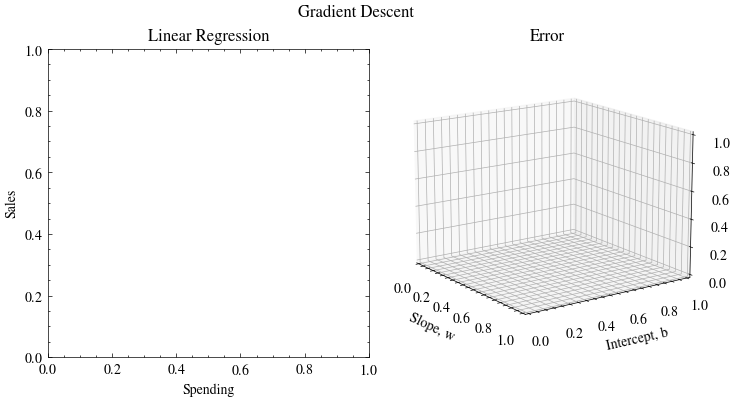

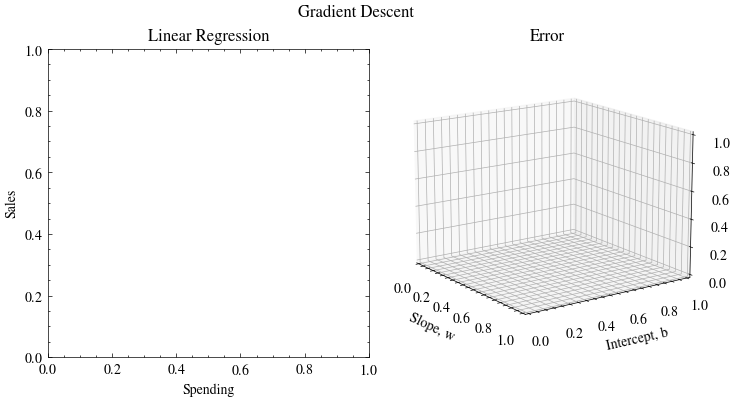

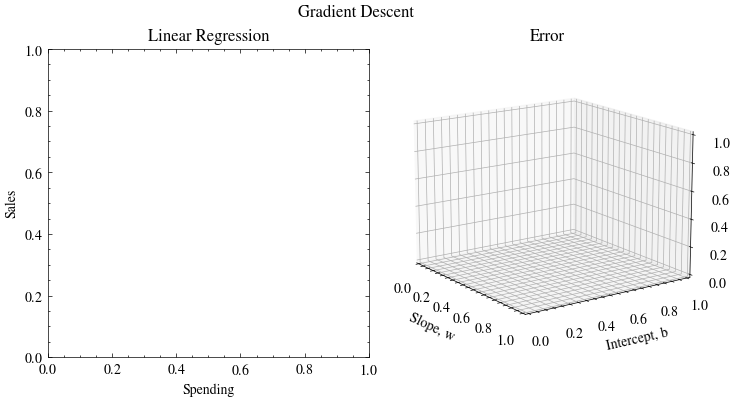

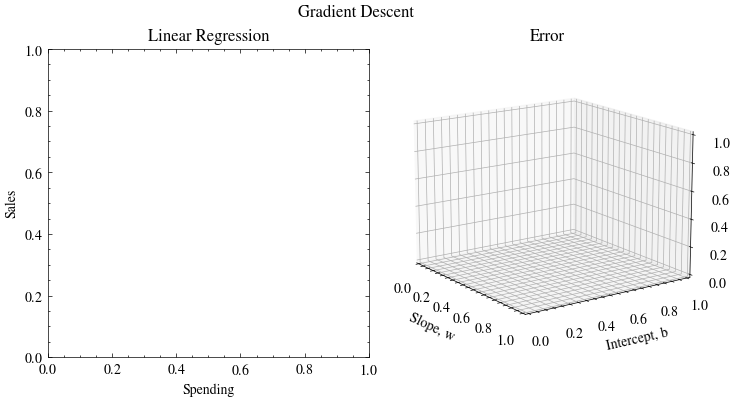

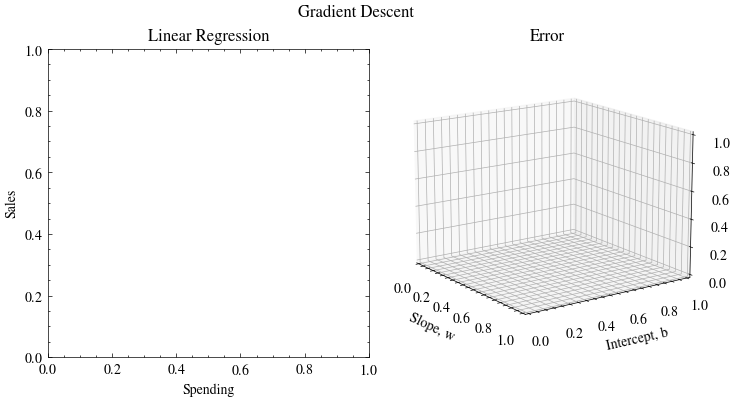

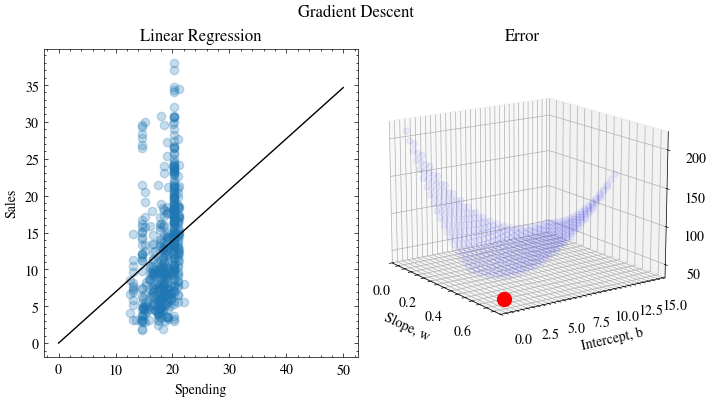

(0.6929666638169472, 0.00990625992144533)

In [23]:
fname = "REGRESSION-gradidentDescent-data.txt"
x , y = np.loadtxt(fname , delimiter = ",", unpack =True , skiprows = 1 , usecols = (10,12))
output_filename = "gradient_descent_animation.gif"
train(x ,y , 0.0 , 0 , 0.00005 , 4000 , output_filename )
